## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Setup**

In [ ]:
n_base       = 20                                            # the student already knows 20 classes
BASE_CLASSES = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2   # SAME order the student was distilled on
META_CLASSES = cfg.SPORTS_META                              # 30 sports MAML meta-trains on (novel)
EXAM_CLASSES = cfg.SPORTS_EXAM                              # 20 NEW held-out sports to adapt to + test (50/50 with base)
n_new        = len(EXAM_CLASSES)

TRAIN_CAP = 12                                # clips/class kept for TRAIN
TEST_CAP  = 10                                # cap for the META pool only; base/exam test are FULL

# MAML meta-training: only the last few backbone blocks (+ LSTM + head) are meta-trained, so base
# features are kept; the head is re-fit afterward (recalibrate_head).
N_WAY = 5; K_SHOT = 3; K_QUERY = 3
POOL_PER_CLASS = 6
META_EPOCHS = 8; META_EPISODES = 60; INNER_STEPS = 5; META_INNER_LR = 0.05; META_LR = 1e-4
META_TRAIN_LAST = 4
HEAD_RECAL_EPOCHS = 3; HEAD_RECAL_LR = 1e-3
FT_EPOCHS = 8                                # plain fine-tune epochs on the meta pool (matched non-meta control for MAML)
FT_LR     = 1e-4

# Adaptation: every method trains ADAPT_EPOCHS epochs on the exam-train set (the ONE adaptation for all arms)
ADAPT_EPOCHS = 5                              # epochs of adaptation on the support
ADAPT_LR     = 3e-4                           # Adam lr during adaptation
K_MAIN = 8                                   # clips/class every method adapts on
REPLAY_PER_CLASS = 8                          # base exemplars/class in the replay buffer
FAIR_LWF = 0.5; FAIR_T = 2.0                  # LwF weight + temperature for the +LwF arms

STUDENT_PATH = f"{cfg.CKPT_DIR}/student.pt"
BASE_ROOT = f"{cfg.DATA_ROOT}/grouped_sbase"
META_ROOT = f"{cfg.DATA_ROOT}/grouped_meta"
EXAM_ROOT = f"{cfg.DATA_ROOT}/grouped_exam"

ALL_CLASSES_LIST = BASE_CLASSES + EXAM_CLASSES + META_CLASSES   # base 0-19, exam 20-39, meta 40-69
class_to_idx = {c: i for i, c in enumerate(ALL_CLASSES_LIST)}
print(f"base {n_base} | meta-train {len(META_CLASSES)} | exam {n_new} | 50/50 new/old = {n_new == n_base}")

base 20 | meta-train 40 | exam 5 | 50/50 new/old = False


## **Preprocess data**

In [6]:
base_split = build_group_split(BASE_CLASSES, train_groups=18, val_groups=3)
meta_split = build_group_split(META_CLASSES, train_groups=18, val_groups=3)
exam_split = build_group_split(EXAM_CLASSES, train_groups=18, val_groups=3)

In [7]:
# BASE (the 20 classes the student knows; base test for retention + replay exemplars)
preprocess_group_split(base_split, BASE_CLASSES, output_root=BASE_ROOT, max_samples=TRAIN_CAP, max_test_samples=None)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_sbase
Classes: 20 | Train limit: 12

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_sbase


In [8]:
# META (novel SPORTS MAML meta-trains on), test stays capped (its clips go into a RAM pool)
preprocess_group_split(meta_split, META_CLASSES, output_root=META_ROOT, max_samples=TRAIN_CAP, max_test_samples=TEST_CAP)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_meta
Classes: 40 | Train limit: 12

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_meta


In [9]:
# EXAM (5 new held-out SPORTS to adapt to and test)
preprocess_group_split(exam_split, EXAM_CLASSES, output_root=EXAM_ROOT, max_samples=TRAIN_CAP, max_test_samples=None)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_exam
Classes: 5 | Train limit: 12

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_exam


## **Create Loaders**

In [10]:
base_train = UCF101Clips(os.path.join(BASE_ROOT, "train"), class_to_idx=class_to_idx)
base_test  = UCF101Clips(os.path.join(BASE_ROOT, "test"),  class_to_idx=class_to_idx)
meta_train = UCF101Clips(os.path.join(META_ROOT,     "train"), class_to_idx=class_to_idx)
exam_train = UCF101Clips(os.path.join(EXAM_ROOT,     "train"), class_to_idx=class_to_idx)
exam_test  = UCF101Clips(os.path.join(EXAM_ROOT,     "test"),  class_to_idx=class_to_idx)

base_train_loader = DataLoader(base_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
base_test_loader  = DataLoader(base_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
exam_train_loader = DataLoader(exam_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
exam_test_loader  = DataLoader(exam_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

pool_meta_clips, pool_meta_labels = build_pool([meta_train], per_class=POOL_PER_CLASS)
meta_ids = sorted(set(pool_meta_labels.tolist()))
print(f"exam train {len(exam_train)} test {len(exam_test)} | meta pool {tuple(pool_meta_clips.shape)} classes {len(meta_ids)}")

exam train 60 test 112 | meta pool (240, 16, 3, 224, 224) classes 40


## **Load the MobileNet student (knows the 20 base classes)**

In [11]:
set_seed(cfg.SEED)
base_model = MobileNetV3SmallLSTMStudent(num_classes=n_base).to(device)
base_model.load_state_dict(torch.load(STUDENT_PATH, map_location=device))
base_head  = copy.deepcopy(base_model.fc)
old_acc_before, _, _ = test_model(base_model, base_test_loader, device)
print(f"base accuracy before adapting: {old_acc_before:.4f}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 61.9MB/s]
                                                         

Test Accuracy: 0.7585
base accuracy before adapting: 0.7585


## **MAML meta-training on the 30 meta sports**

In [12]:
set_seed(cfg.SEED)
meta_model = copy.deepcopy(base_model)
meta_model.fc = nn.Linear(cfg.HIDDEN_SIZE, N_WAY).to(device)
meta_model, hist_maml = meta_train_maml(meta_model, pool_meta_clips, pool_meta_labels, meta_ids,
                                        N_WAY, K_SHOT, K_QUERY, META_EPOCHS, META_EPISODES,
                                        META_INNER_LR, INNER_STEPS, META_LR, device,
                                        freeze_backbone=True, train_last=META_TRAIN_LAST)
meta_model = recalibrate_head(meta_model, base_train_loader, n_base, device, HEAD_RECAL_EPOCHS, HEAD_RECAL_LR)
base_after_meta, _, _ = test_model(meta_model, base_test_loader, device)
print(f"meta init base accuracy after head recalibration: {base_after_meta:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


[maml] epoch 1/8 | meta query acc 0.8311
[maml] epoch 2/8 | meta query acc 0.8833
[maml] epoch 3/8 | meta query acc 0.8767
[maml] epoch 4/8 | meta query acc 0.9156
[maml] epoch 5/8 | meta query acc 0.9522
[maml] epoch 6/8 | meta query acc 0.9556
[maml] epoch 7/8 | meta query acc 0.9633
[maml] epoch 8/8 | meta query acc 0.9789


Test Accuracy: 0.5831
meta init base accuracy after head recalibration: 0.5831


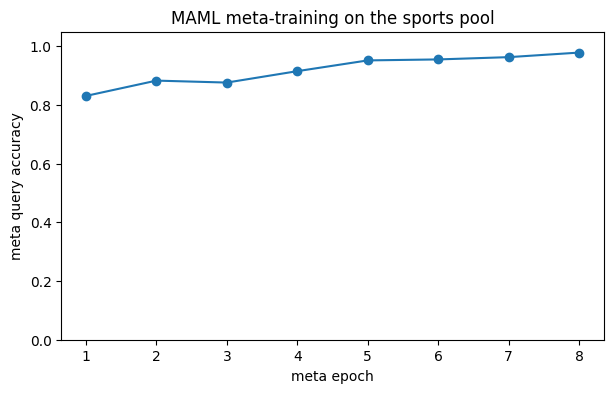

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, META_EPOCHS + 1), hist_maml["query_accs"], marker="o")
plt.xlabel("meta epoch"); plt.ylabel("meta query accuracy"); plt.ylim(0, 1.05)
plt.title("MAML meta-training on the sports pool")
plt.show()

## **Fine-tune baseline (matched control)**

The airtight control for MAML: the SAME student trained on the SAME 30 sports and the SAME parameters
(last blocks + LSTM), but with ordinary supervised training instead of MAML episodes, then the base head
is recalibrated exactly like the MAML init. If MAML beats this, the gain is really from meta-learning; if
they tie, the gain was just the extra sports data.

In [14]:
set_seed(cfg.SEED)
ft_model = copy.deepcopy(base_model)
ft_model = finetune_on_pool(ft_model, pool_meta_clips, pool_meta_labels, meta_ids, device,
                            epochs=FT_EPOCHS, lr=FT_LR, batch_size=cfg.BATCH_SIZE,
                            freeze_backbone=True, train_last=META_TRAIN_LAST)
ft_model = recalibrate_head(ft_model, base_train_loader, n_base, device, HEAD_RECAL_EPOCHS, HEAD_RECAL_LR)
ft_base, _, _ = test_model(ft_model, base_test_loader, device)
print(f"fine-tune init base accuracy after head recalibration: {ft_base:.4f}")
del pool_meta_clips, pool_meta_labels
gc.collect(); torch.cuda.empty_cache()

Test Accuracy: 0.7380
fine-tune init base accuracy after head recalibration: 0.7380


## **Shared replay buffer + LwF teacher**

In [15]:
base_buffer = ReplayBuffer(max_size=REPLAY_PER_CLASS * n_base + 10)
fill_buffer(base_buffer, base_train_loader, per_class=REPLAY_PER_CLASS)
base_teacher = snapshot_teacher(base_model)   # 20-way teacher, protects the base classes via LwF
print(f"replay buffer: {len(base_buffer.data)} base clips")

replay buffer: 160 base clips


## **Adapt each method**

In [16]:
# combined test (for the confusion matrices) and the fair few-shot support
cm_classes  = BASE_CLASSES + EXAM_CLASSES
cm_loader   = DataLoader(ConcatDataset([base_test, exam_test]), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
n_base_test = len(base_test)
n_new_test  = len(exam_test)

# K_MAIN clips per new class, deterministic to every method sees the identical support (fair)
sup_x, sup_y = build_pool([exam_train], per_class=K_MAIN)
main_loader  = DataLoader(TensorDataset(sup_x, sup_y), batch_size=cfg.BATCH_SIZE, shuffle=True)

arms = [
    ("no-meta",          base_model, None,        None),
    ("replay",           base_model, base_buffer, None),
    ("replay+LwF",       base_model, base_buffer, base_teacher),
    ("fine-tune",        ft_model,   None,        None),
    ("fine-tune+replay", ft_model,   base_buffer, None),
    ("fine-tune+replay+LwF", ft_model, base_buffer, base_teacher),
    ("MAML",             meta_model, None,        None),
    ("MAML+replay",      meta_model, base_buffer, None),
    ("MAML+replay+LwF",  meta_model, base_buffer, base_teacher),
]
models = {}
curves = {}
curves_base = {}
RESULTS = []
print(f"{n_base} base + {n_new} new | adapt on {K_MAIN} clips/class for {ADAPT_EPOCHS} epochs | base before {old_acc_before:.3f}")

20 base + 5 new | adapt on 8 clips/class for 5 epochs | base before 0.759


## **no-meta**

Epoch [1/5] | Train Acc: 0.0000 Loss: 4.1701 | Val Acc: 0.0000 Loss: 3.5095
Epoch [2/5] | Train Acc: 0.1000 Loss: 2.8092 | Val Acc: 0.1429 Loss: 2.5362
Epoch [3/5] | Train Acc: 0.5750 Loss: 2.0270 | Val Acc: 0.4554 Loss: 1.9416
Epoch [4/5] | Train Acc: 0.7250 Loss: 1.4367 | Val Acc: 0.5268 Loss: 1.5984
Epoch [5/5] | Train Acc: 0.8000 Loss: 1.0753 | Val Acc: 0.5268 Loss: 1.4162
no-meta: new 0.527 | base 0.189 | balanced 0.358 | harmonic 0.278


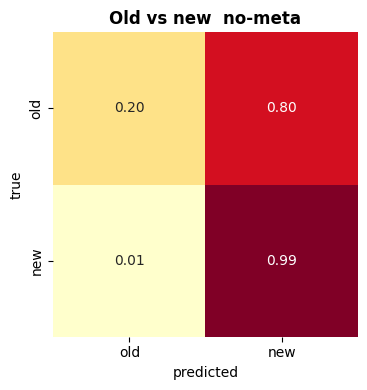

In [17]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(base_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=None, teacher=None,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["no-meta"] = m
curves["no-meta"] = nc
curves_base["no-meta"] = bc
RESULTS.append({"method": "no-meta", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"no-meta: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="no-meta")
torch.cuda.empty_cache()

## **replay**

Epoch [1/5] | Train Acc: 0.4750 Loss: 2.2734 | Val Acc: 0.0000 Loss: 3.5241
Epoch [2/5] | Train Acc: 0.5125 Loss: 1.6258 | Val Acc: 0.0357 Loss: 2.8743
Epoch [3/5] | Train Acc: 0.6375 Loss: 1.2607 | Val Acc: 0.1964 Loss: 2.4366
Epoch [4/5] | Train Acc: 0.8000 Loss: 1.0472 | Val Acc: 0.3304 Loss: 2.1663
Epoch [5/5] | Train Acc: 0.9250 Loss: 0.7024 | Val Acc: 0.2946 Loss: 2.0600
replay: new 0.295 | base 0.676 | balanced 0.486 | harmonic 0.410


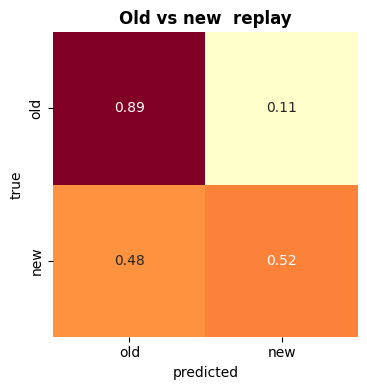

In [18]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(base_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=base_buffer, teacher=None,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["replay"] = m
curves["replay"] = nc
curves_base["replay"] = bc
RESULTS.append({"method": "replay", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"replay: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="replay")
torch.cuda.empty_cache()

## **replay+LwF**

Epoch [1/5] | Train Acc: 0.4750 Loss: 2.5699 | Val Acc: 0.0000 Loss: 3.6836
Epoch [2/5] | Train Acc: 0.5000 Loss: 2.0497 | Val Acc: 0.0000 Loss: 3.1110
Epoch [3/5] | Train Acc: 0.5375 Loss: 1.7148 | Val Acc: 0.0625 Loss: 2.6795
Epoch [4/5] | Train Acc: 0.6750 Loss: 1.4629 | Val Acc: 0.0982 Loss: 2.4888
Epoch [5/5] | Train Acc: 0.7500 Loss: 1.1053 | Val Acc: 0.2232 Loss: 2.2920
replay+LwF: new 0.223 | base 0.724 | balanced 0.474 | harmonic 0.341


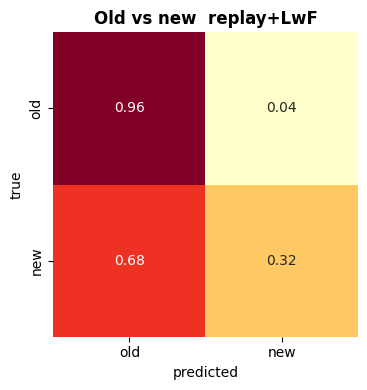

In [19]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(base_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=base_buffer, teacher=base_teacher,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["replay+LwF"] = m
curves["replay+LwF"] = nc
curves_base["replay+LwF"] = bc
RESULTS.append({"method": "replay+LwF", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"replay+LwF: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="replay+LwF")
torch.cuda.empty_cache()

## **fine-tune**

Epoch [1/5] | Train Acc: 0.0500 Loss: 3.1517 | Val Acc: 0.1964 Loss: 2.4788
Epoch [2/5] | Train Acc: 0.4250 Loss: 1.9547 | Val Acc: 0.4911 Loss: 1.8233
Epoch [3/5] | Train Acc: 0.7500 Loss: 1.3367 | Val Acc: 0.4821 Loss: 1.5453
Epoch [4/5] | Train Acc: 0.8250 Loss: 1.0078 | Val Acc: 0.5089 Loss: 1.4146
Epoch [5/5] | Train Acc: 0.8750 Loss: 0.7619 | Val Acc: 0.5000 Loss: 1.3318
fine-tune: new 0.500 | base 0.011 | balanced 0.256 | harmonic 0.022


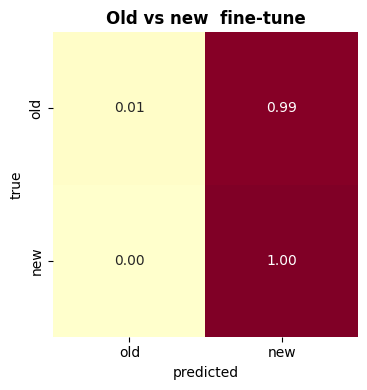

In [20]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(ft_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=None, teacher=None,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["fine-tune"] = m
curves["fine-tune"] = nc
curves_base["fine-tune"] = bc
RESULTS.append({"method": "fine-tune", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"fine-tune: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="fine-tune")
torch.cuda.empty_cache()

## **fine-tune+replay**

Epoch [1/5] | Train Acc: 0.5000 Loss: 1.9204 | Val Acc: 0.1071 Loss: 2.7202
Epoch [2/5] | Train Acc: 0.6750 Loss: 1.3651 | Val Acc: 0.3393 Loss: 2.1480
Epoch [3/5] | Train Acc: 0.8250 Loss: 1.0398 | Val Acc: 0.4464 Loss: 1.8304
Epoch [4/5] | Train Acc: 0.8625 Loss: 0.9551 | Val Acc: 0.4018 Loss: 1.8216
Epoch [5/5] | Train Acc: 0.9625 Loss: 0.6154 | Val Acc: 0.4643 Loss: 1.7912
fine-tune+replay: new 0.464 | base 0.617 | balanced 0.541 | harmonic 0.530


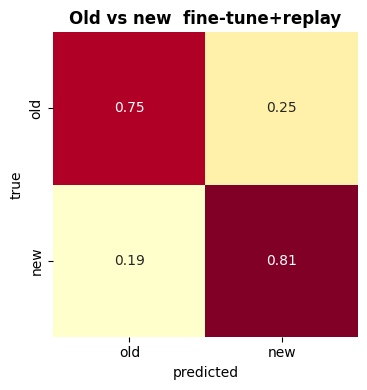

In [21]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(ft_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=base_buffer, teacher=None,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["fine-tune+replay"] = m
curves["fine-tune+replay"] = nc
curves_base["fine-tune+replay"] = bc
RESULTS.append({"method": "fine-tune+replay", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"fine-tune+replay: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="fine-tune+replay")
torch.cuda.empty_cache()

## **fine-tune+replay+LwF**

Epoch [1/5] | Train Acc: 0.5125 Loss: 2.3355 | Val Acc: 0.0446 Loss: 2.7985
Epoch [2/5] | Train Acc: 0.5125 Loss: 1.9474 | Val Acc: 0.2589 Loss: 2.2964
Epoch [3/5] | Train Acc: 0.6875 Loss: 1.5508 | Val Acc: 0.3750 Loss: 1.9264
Epoch [4/5] | Train Acc: 0.8000 Loss: 1.4638 | Val Acc: 0.4107 Loss: 1.7983
Epoch [5/5] | Train Acc: 0.8000 Loss: 1.1152 | Val Acc: 0.4464 Loss: 1.7843
fine-tune+replay+LwF: new 0.446 | base 0.626 | balanced 0.536 | harmonic 0.521


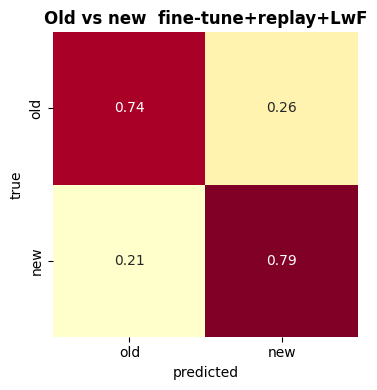

In [22]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(ft_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=base_buffer, teacher=base_teacher,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["fine-tune+replay+LwF"] = m
curves["fine-tune+replay+LwF"] = nc
curves_base["fine-tune+replay+LwF"] = bc
RESULTS.append({"method": "fine-tune+replay+LwF", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"fine-tune+replay+LwF: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="fine-tune+replay+LwF")
torch.cuda.empty_cache()

## **MAML**

Epoch [1/5] | Train Acc: 0.2250 Loss: 2.4561 | Val Acc: 0.2946 Loss: 2.1545
Epoch [2/5] | Train Acc: 0.5000 Loss: 1.6394 | Val Acc: 0.5446 Loss: 1.7139
Epoch [3/5] | Train Acc: 0.6750 Loss: 1.3794 | Val Acc: 0.6339 Loss: 1.4353
Epoch [4/5] | Train Acc: 0.7750 Loss: 1.0264 | Val Acc: 0.5982 Loss: 1.2777
Epoch [5/5] | Train Acc: 0.7250 Loss: 1.0025 | Val Acc: 0.6607 Loss: 1.1541
MAML: new 0.661 | base 0.011 | balanced 0.336 | harmonic 0.022


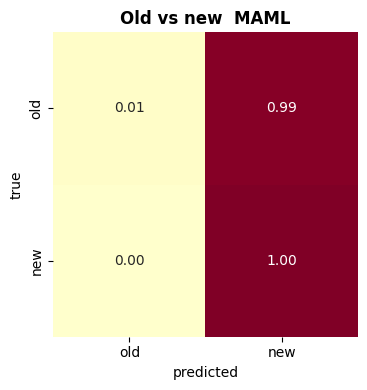

In [23]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(meta_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=None, teacher=None,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["MAML"] = m
curves["MAML"] = nc
curves_base["MAML"] = bc
RESULTS.append({"method": "MAML", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"MAML: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="MAML")
torch.cuda.empty_cache()

## **MAML+replay**

Epoch [1/5] | Train Acc: 0.5000 Loss: 1.7994 | Val Acc: 0.1429 Loss: 2.4471
Epoch [2/5] | Train Acc: 0.6500 Loss: 1.4227 | Val Acc: 0.3661 Loss: 2.0824
Epoch [3/5] | Train Acc: 0.7750 Loss: 1.1200 | Val Acc: 0.4196 Loss: 1.9380
Epoch [4/5] | Train Acc: 0.7250 Loss: 1.1905 | Val Acc: 0.5089 Loss: 1.7577
Epoch [5/5] | Train Acc: 0.8500 Loss: 0.9139 | Val Acc: 0.6250 Loss: 1.5915
MAML+replay: new 0.625 | base 0.576 | balanced 0.601 | harmonic 0.600


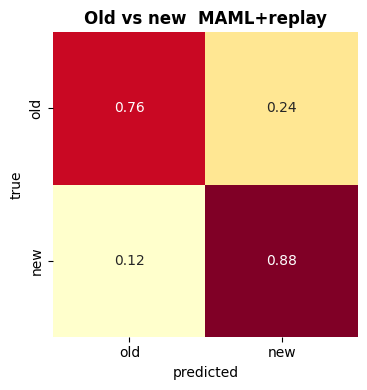

In [24]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(meta_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=base_buffer, teacher=None,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["MAML+replay"] = m
curves["MAML+replay"] = nc
curves_base["MAML+replay"] = bc
RESULTS.append({"method": "MAML+replay", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"MAML+replay: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="MAML+replay")
torch.cuda.empty_cache()

## **MAML+replay+LwF**

Epoch [1/5] | Train Acc: 0.4750 Loss: 2.5681 | Val Acc: 0.0804 Loss: 2.7795
Epoch [2/5] | Train Acc: 0.5500 Loss: 2.1300 | Val Acc: 0.3304 Loss: 2.1362
Epoch [3/5] | Train Acc: 0.7375 Loss: 1.6957 | Val Acc: 0.4018 Loss: 1.8871
Epoch [4/5] | Train Acc: 0.7375 Loss: 1.7455 | Val Acc: 0.4464 Loss: 1.6910
Epoch [5/5] | Train Acc: 0.8125 Loss: 1.3507 | Val Acc: 0.5804 Loss: 1.5238
MAML+replay+LwF: new 0.580 | base 0.542 | balanced 0.561 | harmonic 0.561


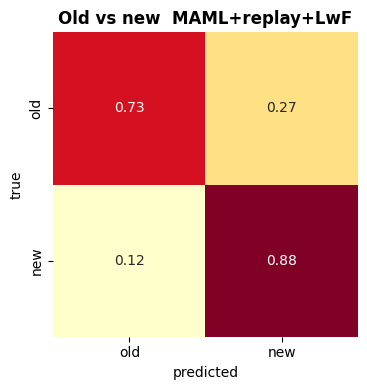

In [25]:
set_seed(cfg.SEED)
m, new_acc, base_acc, nc, bc = adapt_and_eval(copy.deepcopy(meta_model), main_loader, base_test_loader,
                                              exam_test_loader, n_base, n_new, device,
                                              buffer=base_buffer, teacher=base_teacher,
                                              epochs=ADAPT_EPOCHS, lr=ADAPT_LR, lambda_distill=FAIR_LWF, T=FAIR_T)
balanced = (new_acc + base_acc) / 2
harmonic = 2 * new_acc * base_acc / (new_acc + base_acc + 1e-9)
models["MAML+replay+LwF"] = m
curves["MAML+replay+LwF"] = nc
curves_base["MAML+replay+LwF"] = bc
RESULTS.append({"method": "MAML+replay+LwF", "new_acc": round(new_acc, 3),
                "base_acc": round(base_acc, 3), "balanced": round(balanced, 3), "harmonic": round(harmonic, 3)})
print(f"MAML+replay+LwF: new {new_acc:.3f} | base {base_acc:.3f} | balanced {balanced:.3f} | harmonic {harmonic:.3f}")
_, preds, labels = test_model(m, cm_loader, device, verbose=False)
plot_old_new_confusion(labels, preds, n_base, name="MAML+replay+LwF")
torch.cuda.empty_cache()

## **Adaptation curves**

New-class accuracy per epoch (left) and base retention per epoch (right). Steeper new-class line = learns
faster; flat, high base line = forgets less.

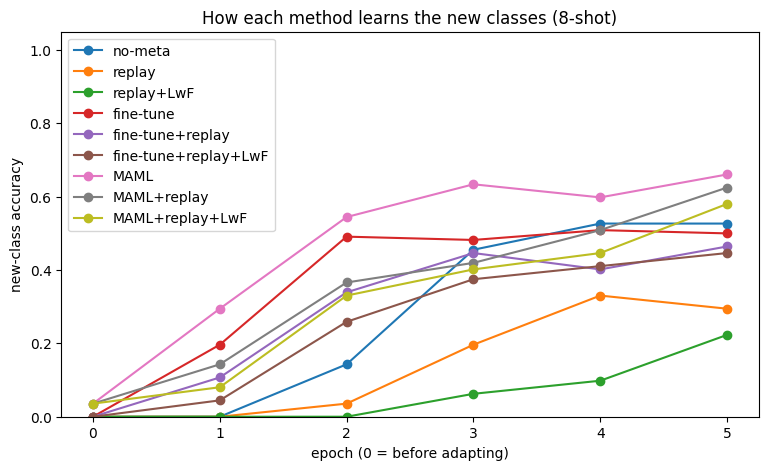

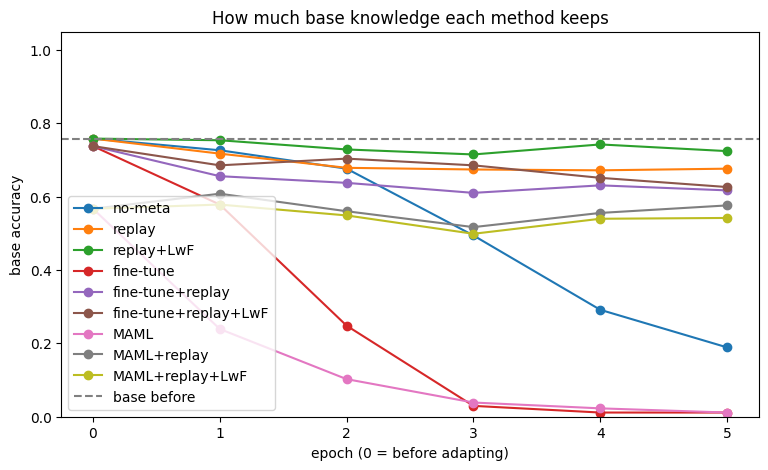

In [26]:
plt.figure(figsize=(9, 5))
for name in curves:
    plt.plot(range(len(curves[name])), curves[name], marker="o", label=name)
plt.xlabel("epoch (0 = before adapting)"); plt.ylabel("new-class accuracy"); plt.ylim(0, 1.05)
plt.title(f"How each method learns the new classes ({K_MAIN}-shot)"); plt.legend(); plt.show()

plt.figure(figsize=(9, 5))
for name in curves_base:
    plt.plot(range(len(curves_base[name])), curves_base[name], marker="o", label=name)
plt.axhline(old_acc_before, ls="--", color="gray", label="base before")
plt.xlabel("epoch (0 = before adapting)"); plt.ylabel("base accuracy"); plt.ylim(0, 1.05)
plt.title("How much base knowledge each method keeps"); plt.legend(); plt.show()

## **Compare all methods (K_MAIN-shot)**

8-shot, 5 epochs (base before adapting 0.759):
              method  new_acc  base_acc  balanced  harmonic
         MAML+replay    0.625     0.576     0.601     0.600
     MAML+replay+LwF    0.580     0.542     0.561     0.561
    fine-tune+replay    0.464     0.617     0.541     0.530
fine-tune+replay+LwF    0.446     0.626     0.536     0.521
              replay    0.295     0.676     0.486     0.410
          replay+LwF    0.223     0.724     0.474     0.341
             no-meta    0.527     0.189     0.358     0.278
           fine-tune    0.500     0.011     0.256     0.022
                MAML    0.661     0.011     0.336     0.022


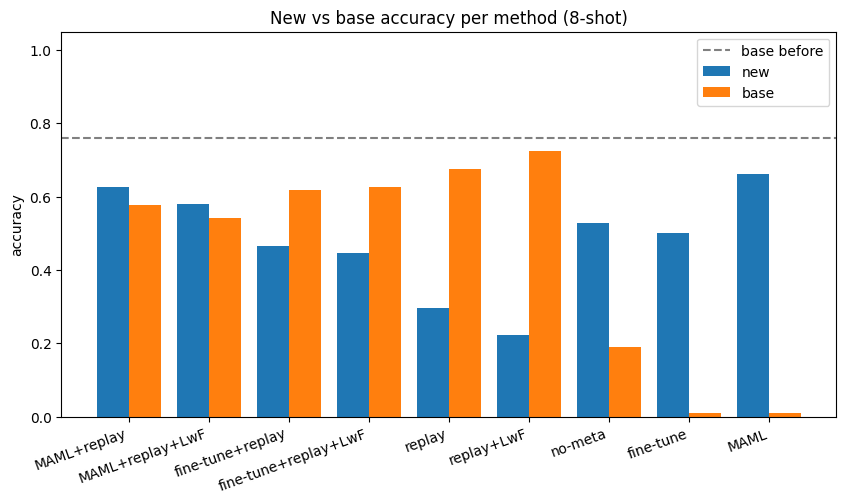

In [27]:
compare_df = pd.DataFrame(RESULTS).sort_values("harmonic", ascending=False).reset_index(drop=True)
print(f"{K_MAIN}-shot, {ADAPT_EPOCHS} epochs (base before adapting {old_acc_before:.3f}):")
print(compare_df.to_string(index=False))

x = np.arange(len(compare_df))
w = 0.4
plt.figure(figsize=(10, 5))
plt.bar(x - w / 2, compare_df["new_acc"],  w, label="new")
plt.bar(x + w / 2, compare_df["base_acc"], w, label="base")
plt.axhline(old_acc_before, ls="--", color="gray", label="base before")
plt.xticks(x, compare_df["method"], rotation=20, ha="right"); plt.ylim(0, 1.05)
plt.ylabel("accuracy"); plt.title(f"New vs base accuracy per method ({K_MAIN}-shot)"); plt.legend(); plt.show()

## **Shots sweep**

New-class accuracy as the number of support clips per class grows. Same fair adaptation as above, just
with fewer/more clips, fewer clips make the starting point matter more, so the MAML arms should sit
above their plain twins at the low end. Only the summary line per shot is printed.

shots  1: no-meta 0.00 | replay 0.00 | replay+LwF 0.00 | fine-tune 0.03 | fine-tune+replay 0.00 | fine-tune+replay+LwF 0.02 | MAML 0.26 | MAML+replay 0.16 | MAML+replay+LwF 0.12
shots  3: no-meta 0.13 | replay 0.04 | replay+LwF 0.00 | fine-tune 0.37 | fine-tune+replay 0.22 | fine-tune+replay+LwF 0.10 | MAML 0.42 | MAML+replay 0.19 | MAML+replay+LwF 0.10
shots  5: no-meta 0.43 | replay 0.23 | replay+LwF 0.08 | fine-tune 0.54 | fine-tune+replay 0.34 | fine-tune+replay+LwF 0.35 | MAML 0.55 | MAML+replay 0.44 | MAML+replay+LwF 0.35
shots 10: no-meta 0.66 | replay 0.45 | replay+LwF 0.38 | fine-tune 0.59 | fine-tune+replay 0.49 | fine-tune+replay+LwF 0.47 | MAML 0.65 | MAML+replay 0.55 | MAML+replay+LwF 0.50


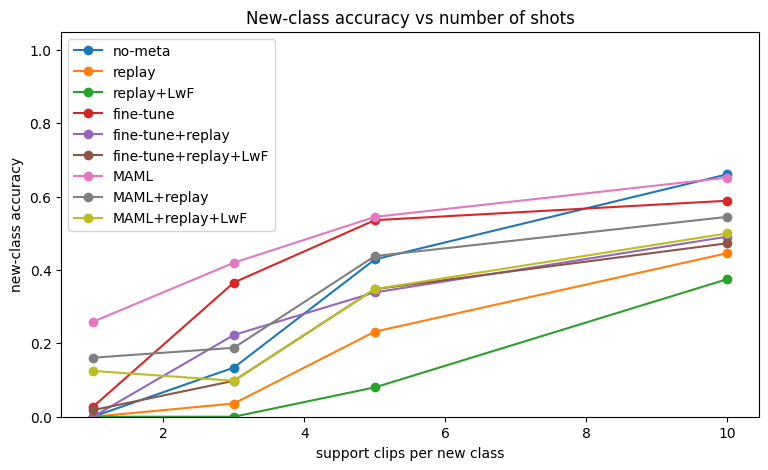

In [28]:
SHOTS = [1, 3, 5, 10]
sweep = {name: [] for name, _, _, _ in arms}
for k in SHOTS:
    kx, ky = build_pool([exam_train], per_class=k)
    kloader = DataLoader(TensorDataset(kx, ky), batch_size=cfg.BATCH_SIZE, shuffle=True)
    for name, init, buf, teach in arms:
        set_seed(cfg.SEED)
        _, new_acc, _, _, _ = adapt_and_eval(copy.deepcopy(init), kloader, base_test_loader,
                                             exam_test_loader, n_base, n_new, device,
                                             buffer=buf, teacher=teach, epochs=ADAPT_EPOCHS, lr=ADAPT_LR,
                                             lambda_distill=FAIR_LWF, T=FAIR_T, verbose=False, track=False)
        sweep[name].append(round(new_acc, 3))
    torch.cuda.empty_cache()
    print(f"shots {k:2d}: " + " | ".join(f"{n} {sweep[n][-1]:.2f}" for n in sweep))

plt.figure(figsize=(9, 5))
for name in sweep:
    plt.plot(SHOTS, sweep[name], marker="o", label=name)
plt.xlabel("support clips per new class"); plt.ylabel("new-class accuracy"); plt.ylim(0, 1.05)
plt.title("New-class accuracy vs number of shots"); plt.legend(); plt.show()

## **1-shot comparison**

1-shot new-class accuracy:
MAML                    0.259
MAML+replay             0.161
MAML+replay+LwF         0.125
fine-tune               0.027
fine-tune+replay+LwF    0.018
no-meta                 0.000
fine-tune+replay        0.000
replay                  0.000
replay+LwF              0.000


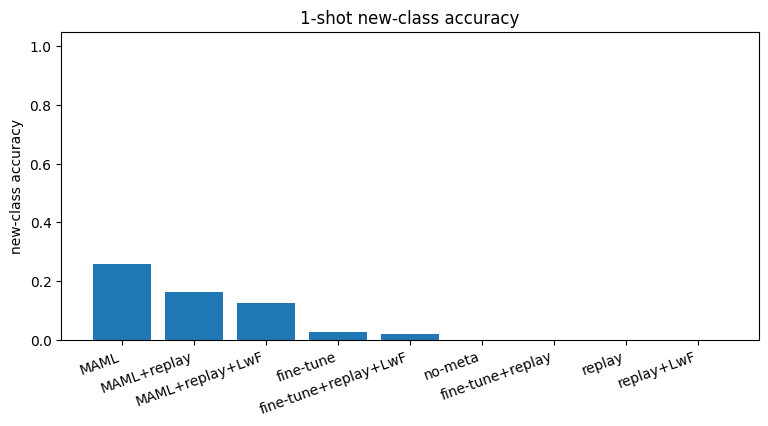

In [29]:
one_shot = pd.Series({name: sweep[name][0] for name in sweep}).sort_values(ascending=False)
print("1-shot new-class accuracy:")
print(one_shot.to_string())

plt.figure(figsize=(9, 4))
plt.bar(range(len(one_shot)), one_shot.values)
plt.xticks(range(len(one_shot)), one_shot.index, rotation=20, ha="right"); plt.ylim(0, 1.05)
plt.ylabel("new-class accuracy"); plt.title("1-shot new-class accuracy"); plt.show()

## **Best method across shots**

best method by average new-class accuracy across shots: MAML (0.469)


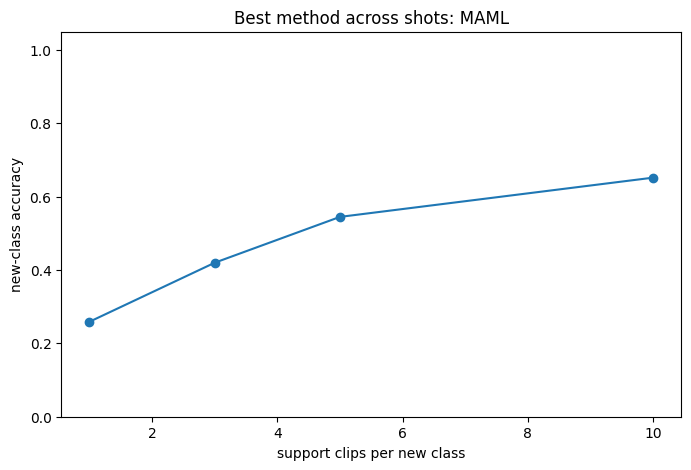

In [30]:
mean_new = {name: sum(sweep[name]) / len(sweep[name]) for name in sweep}
best = max(mean_new, key=mean_new.get)
print(f"best method by average new-class accuracy across shots: {best} ({mean_new[best]:.3f})")

plt.figure(figsize=(8, 5))
plt.plot(SHOTS, sweep[best], marker="o")
plt.xlabel("support clips per new class"); plt.ylabel("new-class accuracy"); plt.ylim(0, 1.05)
plt.title(f"Best method across shots: {best}"); plt.show()

## **Prototype test (meta features)**

Did meta-training reshape the features? Nearest-class-mean accuracy on the meta classes, plain student vs
meta-trained one (features only, no head).

In [31]:
meta_train_loader = DataLoader(meta_train, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
meta_test        = UCF101Clips(os.path.join(META_ROOT, "test"), class_to_idx=class_to_idx)
meta_test_loader = DataLoader(meta_test, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

plain_proto = proto_accuracy(base_model, meta_train_loader, meta_test_loader, device)
meta_proto  = proto_accuracy(meta_model, meta_train_loader, meta_test_loader, device)
print(f"prototype accuracy on the meta classes: plain {plain_proto:.3f} | meta-trained {meta_proto:.3f}")

prototype accuracy on the meta classes: plain 0.247 | meta-trained 0.270


## **Final scores table**

In [32]:
rows = []
for name in models:
    _, preds, labels = test_model(models[name], cm_loader, device, verbose=False)
    preds = np.array(preds); labels = np.array(labels)
    base_mask = labels < n_base
    new_mask  = labels >= n_base
    p, r, f, _ = precision_recall_fscore_support(labels, preds, labels=list(range(n_base + n_new)),
                                                 average=None, zero_division=0)
    na = float((preds[new_mask]  == labels[new_mask]).mean())
    ba = float((preds[base_mask] == labels[base_mask]).mean())
    rows.append({"method": name,
                 "new_acc":  round(na, 3), "base_acc": round(ba, 3),
                 "balanced": round((na + ba) / 2, 3),
                 "harmonic": round(2 * na * ba / (na + ba + 1e-9), 3),
                 "new_f1":   round(float(f[n_base:].mean()), 3),
                 "base_f1":  round(float(f[:n_base].mean()), 3)})
scores_df = pd.DataFrame(rows).sort_values("harmonic", ascending=False).reset_index(drop=True)
print(scores_df.to_string(index=False))

              method  new_acc  base_acc  balanced  harmonic  new_f1  base_f1
         MAML+replay    0.625     0.576     0.601     0.600   0.449    0.609
     MAML+replay+LwF    0.580     0.542     0.561     0.561   0.417    0.581
    fine-tune+replay    0.464     0.617     0.541     0.530   0.359    0.667
fine-tune+replay+LwF    0.446     0.626     0.536     0.521   0.347    0.673
              replay    0.295     0.677     0.486     0.411   0.302    0.648
          replay+LwF    0.223     0.724     0.474     0.341   0.270    0.679
             no-meta    0.527     0.189     0.358     0.278   0.207    0.255
           fine-tune    0.500     0.011     0.256     0.022   0.176    0.021
                MAML    0.661     0.011     0.336     0.022   0.253    0.020


## **Save**

In [33]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"n_base": n_base, "n_new": n_new, "n_meta": len(META_CLASSES),
           "adapt_epochs": ADAPT_EPOCHS, "k_main": K_MAIN,
           "old_acc_before": old_acc_before,
           "results": RESULTS, "sweep": sweep, "best_method": best,
           "proto": {"plain": plain_proto, "meta_trained": meta_proto},
           "maml_curve": hist_maml["query_accs"]}
with open(f"{cfg.RESULTS_DIR}/stage5_meta_vs_rehearsal.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/stage5_meta_vs_rehearsal.json")

saved -> /content/drive/MyDrive/apai/results/stage5_meta_vs_rehearsal.json
